**Sub questions:**
- (a) Gamma correction with γ = 0.5
- (b) Gamma correction with γ = 2.0
- (c) Contrast Stretching with r1 = 0.2, r2 = 0.8

**Image:** `runway.png`


In [10]:
import sys
print("Python:", sys.executable)

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy
print("cv2        :", cv.__version__)
print("numpy      :", np.__version__)
print("scipy      :", scipy.__version__)

# Load the runway image as grayscale
img = cv.imread('../images/runway.png', cv.IMREAD_GRAYSCALE)
assert img is not None, "Could not load runway.png — check the path"

# Normalize to [0, 1] float32 — required for power-law transforms
f = img.astype(np.float32) / 255.0

print(f"Image shape : {img.shape}")
print(f"Dtype       : {img.dtype}")
print(f"Min / Max   : {img.min()} / {img.max()}")
print(f"Mean        : {img.mean():.2f}  (>127 means image is bright/overexposed)")
print(f"Std Dev     : {img.std():.2f}")


Python: E:\Study materials\UOM\1st Year\3rd Semester\Computer Vision\cv-assignment-01\venv\Scripts\python.exe
cv2        : 4.13.0
numpy      : 2.4.4
scipy      : 1.17.1
Image shape : (769, 765)
Dtype       : uint8
Min / Max   : 0 / 255
Mean        : 197.12  (>127 means image is bright/overexposed)
Std Dev     : 40.88


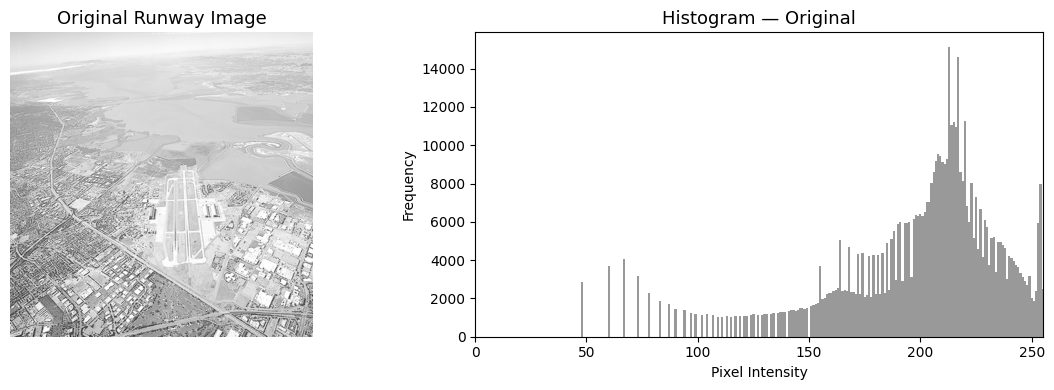

In [11]:
# Visualize the original image and its histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Runway Image', fontsize=13)
axes[0].axis('off')

hist_orig = np.histogram(img.ravel(), bins=256, range=(0, 256))[0]
axes[1].bar(range(256), hist_orig, color='gray', alpha=0.8, width=1.0)
axes[1].set_title('Histogram — Original', fontsize=13)
axes[1].set_xlabel('Pixel Intensity')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim([0, 255])

plt.tight_layout()
os.makedirs('../outputs/q1', exist_ok=True)
plt.savefig('../outputs/q1/q1_original.png', dpi=150, bbox_inches='tight')
plt.show()


## (a) & (b) Gamma Correction


In [12]:
def gamma_correction(image_norm, gamma):
    """
    Apply gamma correction to a normalized [0,1] float image.
    Formula: s = r^gamma
    Returns: uint8 image in range [0, 255]
    """
    corrected = np.power(image_norm, gamma)
    return (corrected * 255).astype(np.uint8)


# (a) gamma = 0.5 — brightens the image
gamma_05 = gamma_correction(f, 0.5)

# (b) gamma = 2.0 — darkens the image
gamma_2  = gamma_correction(f, 2.0)

print(f"Original  — mean: {img.mean():.1f} | std: {img.std():.1f}")
print(f"Gamma 0.5 — mean: {gamma_05.mean():.1f} | std: {gamma_05.std():.1f}")
print(f"Gamma 2.0 — mean: {gamma_2.mean():.1f}  | std: {gamma_2.std():.1f}")


Original  — mean: 197.1 | std: 40.9
Gamma 0.5 — mean: 222.0 | std: 27.0
Gamma 2.0 — mean: 158.5  | std: 54.5


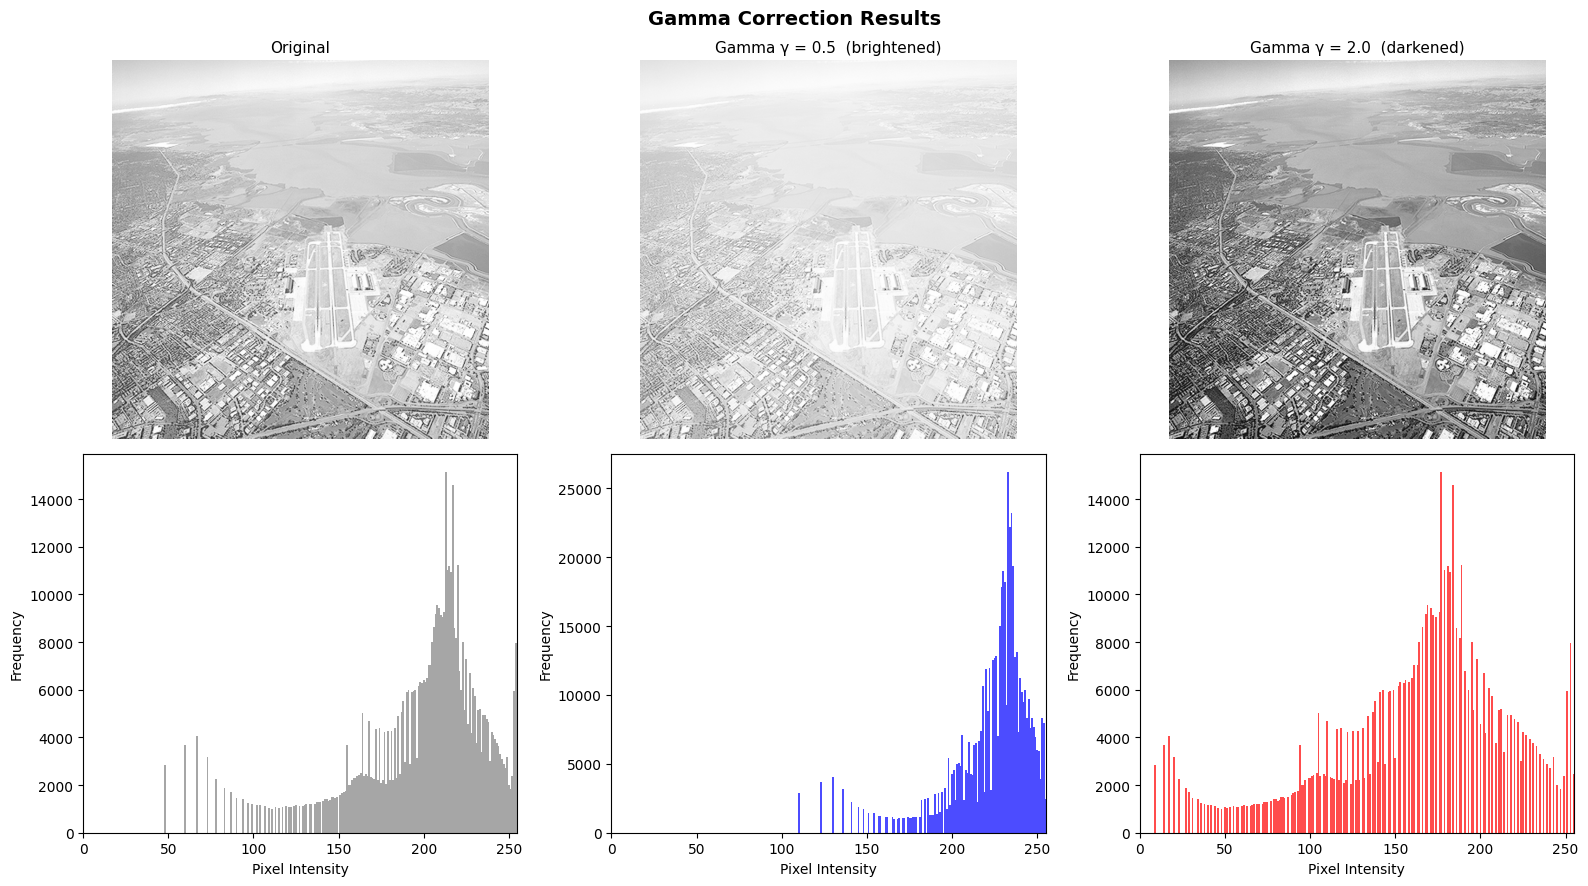

In [13]:
# Plot gamma results with histograms
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Gamma Correction Results', fontsize=14, fontweight='bold')

images = [img, gamma_05, gamma_2]
titles = ['Original', 'Gamma γ = 0.5  (brightened)', 'Gamma γ = 2.0  (darkened)']
colors = ['gray', 'blue', 'red']

for col, (image, title, color) in enumerate(zip(images, titles, colors)):
    hist = np.histogram(image.ravel(), bins=256, range=(0, 256))[0]

    axes[0, col].imshow(image, cmap='gray', vmin=0, vmax=255)
    axes[0, col].set_title(title, fontsize=11)
    axes[0, col].axis('off')

    axes[1, col].bar(range(256), hist, color=color, alpha=0.7, width=1.0)
    axes[1, col].set_xlabel('Pixel Intensity')
    axes[1, col].set_ylabel('Frequency')
    axes[1, col].set_xlim([0, 255])

plt.tight_layout()
plt.savefig('../outputs/q1/q1_gamma_results.png', dpi=150, bbox_inches='tight')
plt.show()


## (c) Contrast Stretching


In [14]:
def contrast_stretch(image_norm, r1=0.2, r2=0.8):
    """
    Piecewise linear contrast stretching.
    Input:  normalized float32 image in [0, 1]
    Output: uint8 image in [0, 255]
    """
    s = np.zeros_like(image_norm, dtype=np.float32)

    # Region 1: r < r1  →  s = 0  (already zero from np.zeros_like)

    # Region 2: r1 <= r <= r2  →  linear stretch
    mid_mask = (image_norm >= r1) & (image_norm <= r2)
    s[mid_mask] = (image_norm[mid_mask] - r1) / (r2 - r1)

    # Region 3: r > r2  →  s = 1
    s[image_norm > r2] = 1.0

    return (s * 255).astype(np.uint8)


contrast_stretched = contrast_stretch(f, r1=0.2, r2=0.8)
print(f"Contrast Stretch — mean: {contrast_stretched.mean():.1f} | std: {contrast_stretched.std():.1f}")


Contrast Stretch — mean: 225.2 | std: 54.0


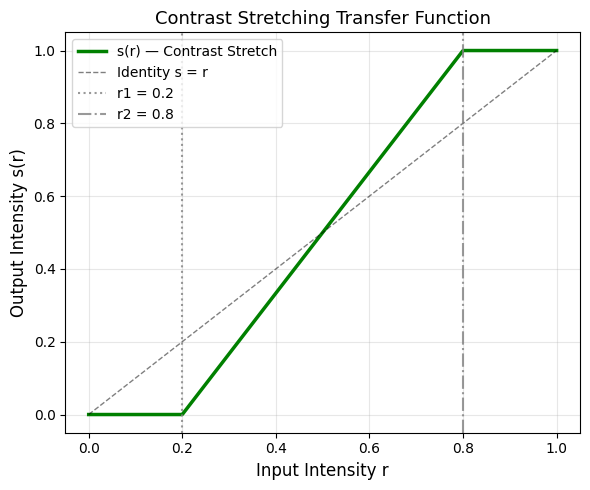

In [15]:
# Plot the transfer function curve
r_vals = np.linspace(0, 1, 500)
s_vals = np.zeros_like(r_vals)
mid = (r_vals >= 0.2) & (r_vals <= 0.8)
s_vals[mid]          = (r_vals[mid] - 0.2) / (0.8 - 0.2)
s_vals[r_vals > 0.8] = 1.0

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(r_vals, s_vals, color='green', linewidth=2.5, label='s(r) — Contrast Stretch')
ax.plot([0, 1],  [0, 1],  'k--', linewidth=1, alpha=0.5, label='Identity s = r')
ax.axvline(0.2, color='gray', linestyle=':',  alpha=0.8, label='r1 = 0.2')
ax.axvline(0.8, color='gray', linestyle='-.', alpha=0.8, label='r2 = 0.8')
ax.set_xlabel('Input Intensity r', fontsize=12)
ax.set_ylabel('Output Intensity s(r)', fontsize=12)
ax.set_title('Contrast Stretching Transfer Function', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/q1/q1_contrast_stretch_curve.png', dpi=150, bbox_inches='tight')
plt.show()


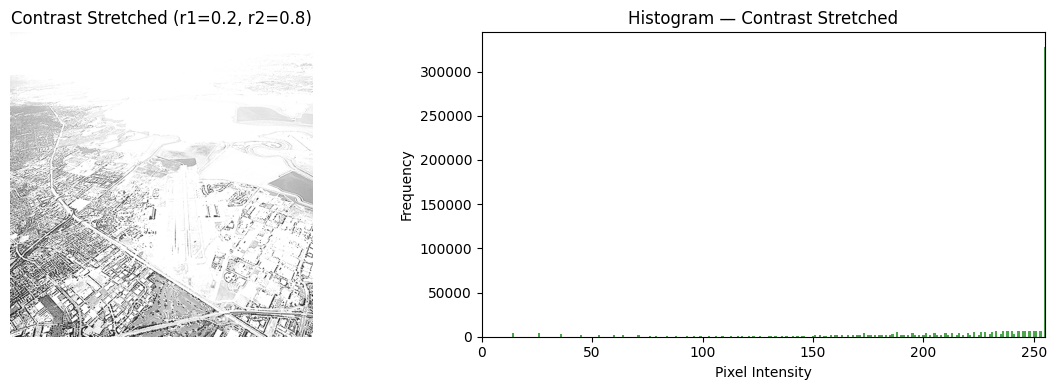

In [16]:
# Show contrast stretch result and histogram
hist_stretch = np.histogram(contrast_stretched.ravel(), bins=256, range=(0, 256))[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(contrast_stretched, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Contrast Stretched (r1=0.2, r2=0.8)', fontsize=12)
axes[0].axis('off')

axes[1].bar(range(256), hist_stretch, color='green', alpha=0.7, width=1.0)
axes[1].set_title('Histogram — Contrast Stretched', fontsize=12)
axes[1].set_xlabel('Pixel Intensity')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim([0, 255])
plt.tight_layout()
plt.savefig('../outputs/q1/q1_contrast_stretch_result.png', dpi=150, bbox_inches='tight')
plt.show()


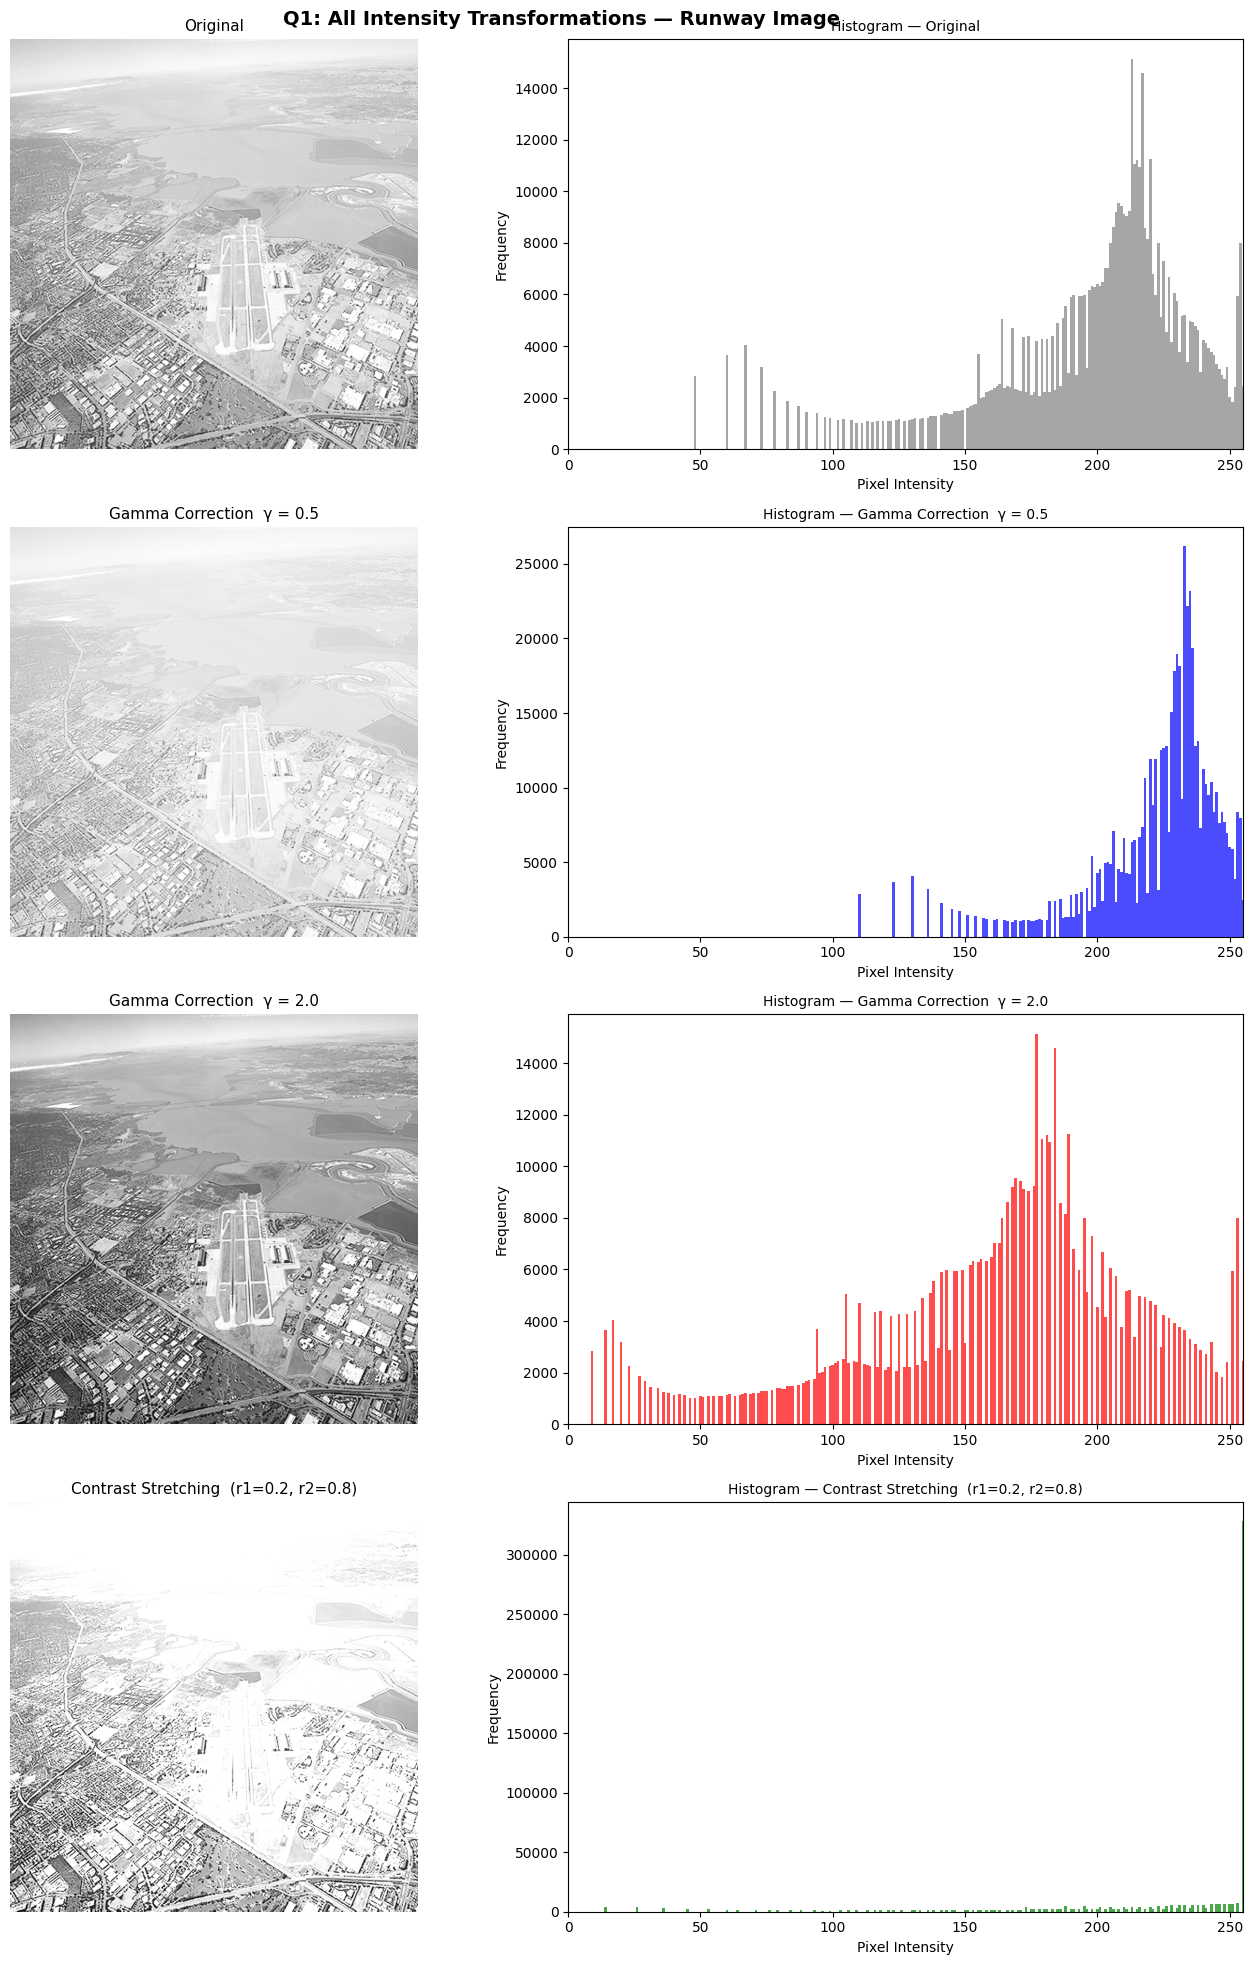

In [17]:
# Final summary — all 4 results in one figure
fig, axes = plt.subplots(4, 2, figsize=(14, 20))
fig.suptitle('Q1: All Intensity Transformations — Runway Image', fontsize=14, fontweight='bold')

all_images = [img,    gamma_05,              gamma_2,               contrast_stretched]
all_titles = ['Original',
              'Gamma Correction  γ = 0.5',
              'Gamma Correction  γ = 2.0',
              'Contrast Stretching  (r1=0.2, r2=0.8)']
all_colors = ['gray', 'blue', 'red', 'green']

for row, (image, title, color) in enumerate(zip(all_images, all_titles, all_colors)):
    hist = np.histogram(image.ravel(), bins=256, range=(0, 256))[0]
    axes[row, 0].imshow(image, cmap='gray', vmin=0, vmax=255)
    axes[row, 0].set_title(title, fontsize=11)
    axes[row, 0].axis('off')
    axes[row, 1].bar(range(256), hist, color=color, alpha=0.7, width=1.0)
    axes[row, 1].set_title(f'Histogram — {title}', fontsize=10)
    axes[row, 1].set_xlabel('Pixel Intensity')
    axes[row, 1].set_ylabel('Frequency')
    axes[row, 1].set_xlim([0, 255])

plt.tight_layout()
plt.savefig('../outputs/q1/q1_all_transforms.png', dpi=150, bbox_inches='tight')
plt.show()


In [18]:
# Statistics summary table
print(f"{'Transform':<25} {'Mean':>8} {'Std':>8} {'Min':>6} {'Max':>6}")
print("-" * 58)
for name, image in [('Original',         img),
                    ('Gamma  γ = 0.5',    gamma_05),
                    ('Gamma  γ = 2.0',    gamma_2),
                    ('Contrast Stretch',  contrast_stretched)]:
    print(f"{name:<25} {image.mean():>8.1f} {image.std():>8.1f} "
          f"{int(image.min()):>6} {int(image.max()):>6}")


Transform                     Mean      Std    Min    Max
----------------------------------------------------------
Original                     197.1     40.9      0    255
Gamma  γ = 0.5               222.0     27.0      0    255
Gamma  γ = 2.0               158.5     54.5      0    255
Contrast Stretch             225.2     54.0      0    255
